<a href="https://colab.research.google.com/github/Daniel211298/cmapss-turbine-rul/blob/main/DigitalTwin(NASA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Digital Twin : NASA C-MAPSS-1 Turbofan Engine Degradation**



In [ ]:
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
colunas = [
    'unit number',
    'time (cicles)',
    's1',
    's2',
    's3',
    'm1',
    'm2',
    'm3',
    'm4',
    'm5',
    'm6',
    'm7',
    'm8',
    'm9',
    'm10',
    'm11',
    'm12',
    'm13',
    'm14',
    'm15',
    'm16',
    'm17',
    'm18',
    'm19',
    'm20',
    'm21',
    'm22',
    'm23',
    'm24',
    'm25',
    'm26',
]

In [ ]:
df = pd.read_csv("test_FD001.txt", sep=r'\s+', header=None, names=colunas)
df.dropna(axis=1, how='all', inplace=True)
df.head()

,unit number,time (cicles),s1,s2,s3,m1,m2,m3,m4,m5,...,m12,m13,m14,m15,m16,m17,m18,m19,m20,m21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13096 entries, 0 to 13095
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   unit number    13096 non-null  int64  
 1   time (cicles)  13096 non-null  int64  
 2   s1             13096 non-null  float64
 3   s2             13096 non-null  float64
 4   s3             13096 non-null  float64
 5   m1             13096 non-null  float64
 6   m2             13096 non-null  float64
 7   m3             13096 non-null  float64
 8   m4             13096 non-null  float64
 9   m5             13096 non-null  float64
 10  m6             13096 non-null  float64
 11  m7             13096 non-null  float64
 12  m8             13096 non-null  float64
 13  m9             13096 non-null  float64
 14  m10            13096 non-null  float64
 15  m11            13096 non-null  float64
 16  m12            13096 non-null  float64
 17  m13            13096 non-null  float64
 18  m14   

In [ ]:
# Estatísticas descritivas
df.describe()

# Verificando valores nulos
df.isnull().sum()

,0
unit number,0
time (cicles),0
s1,0
s2,0
s3,0
m1,0
m2,0
m3,0
m4,0
m5,0


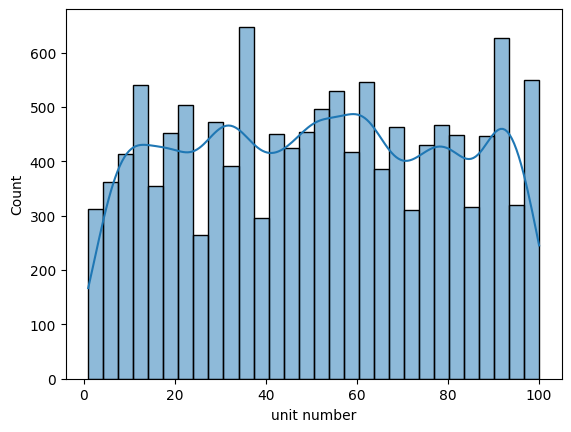

In [ ]:
sns.histplot(df["unit number"], bins=30, kde=True)
plt.show()

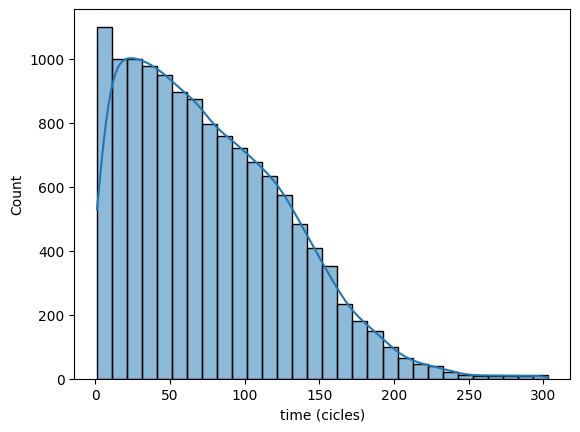

In [ ]:
sns.histplot(df["time (cicles)"], bins=30, kde=True)
plt.show()

In [ ]:
# Ciclo máximo de cada motor
max_ciclo = df.groupby('unit number')['time (cicles)'].max()

# Junta com o df original e calcula RUL
df['max_cycle'] = df['unit number'].map(max_ciclo)
df['RUL'] = df['max_cycle'] - df['time (cicles)']

# Remove a coluna auxiliar
df.drop(columns=['max_cycle'], inplace=True)

df[['unit number', 'time (cicles)', 'RUL']].head(10)

,unit number,time (cicles),RUL
0,1,1,30
1,1,2,29
2,1,3,28
3,1,4,27
4,1,5,26
5,1,6,25
6,1,7,24
7,1,8,23
8,1,9,22
9,1,10,21


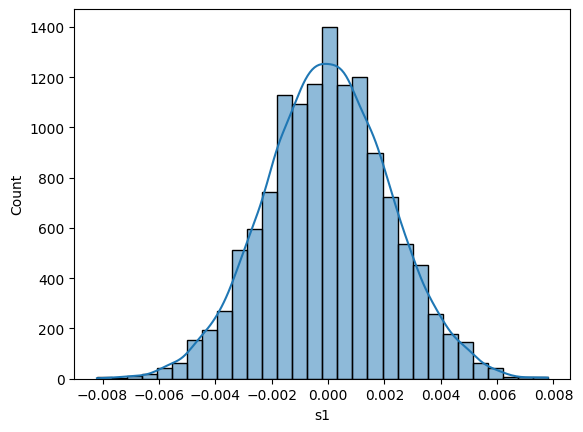

In [ ]:
sns.histplot(df["s1"], bins=30, kde=True)
plt.show()

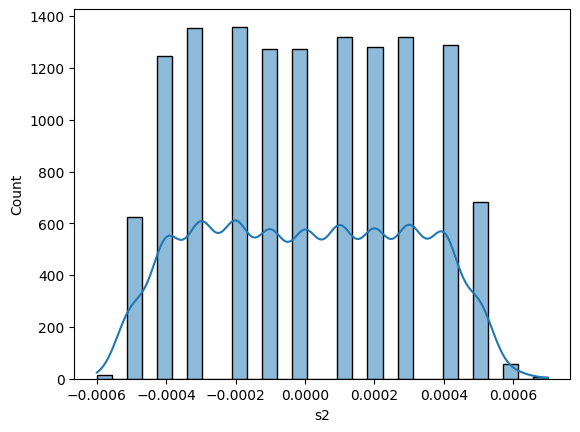

In [ ]:
sns.histplot(df["s2"], bins=30, kde=True)
plt.show()

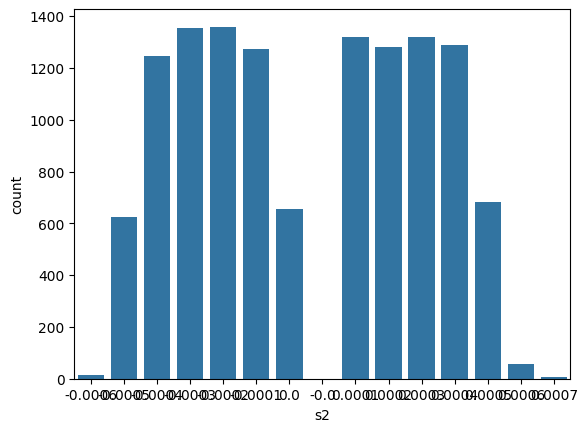

In [ ]:
sns.countplot(x="s2", data=df)
plt.show()

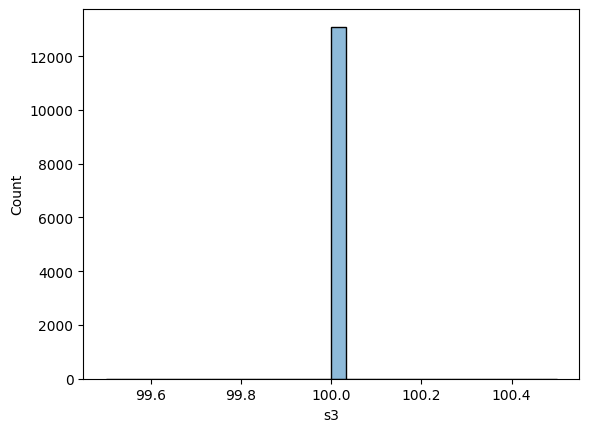

In [ ]:
sns.histplot(df["s3"], bins=30, kde=True)
plt.show()

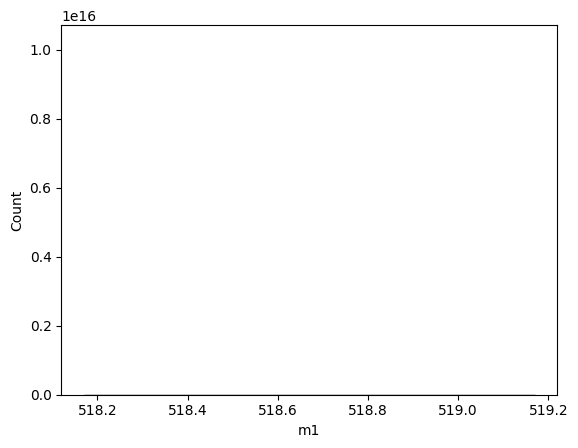

In [ ]:
sns.histplot(df["m1"], bins=30, kde=True)
plt.show()

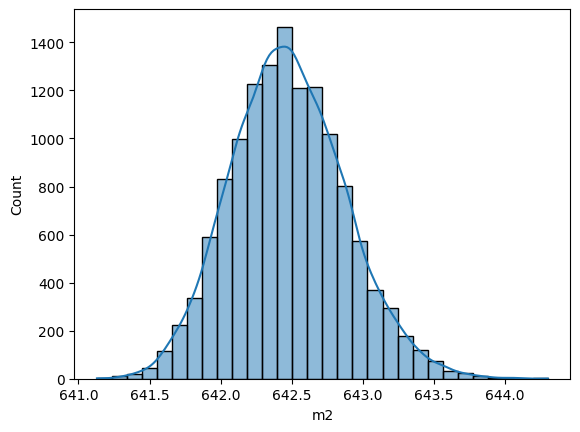

In [ ]:
sns.histplot(df["m2"], bins=30, kde=True)
plt.show()

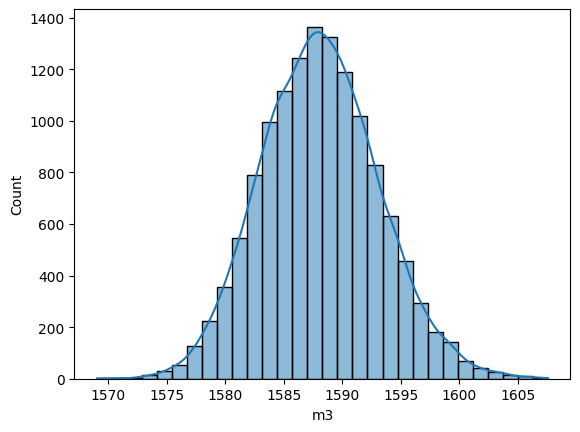

In [ ]:
sns.histplot(df["m3"], bins=30, kde=True)
plt.show()

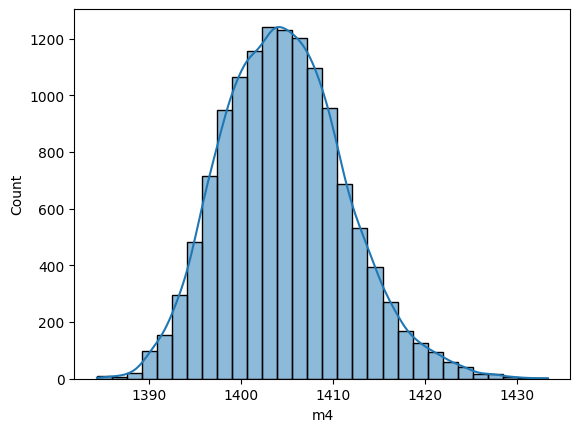

In [ ]:
sns.histplot(df["m4"], bins=30, kde=True)
plt.show()

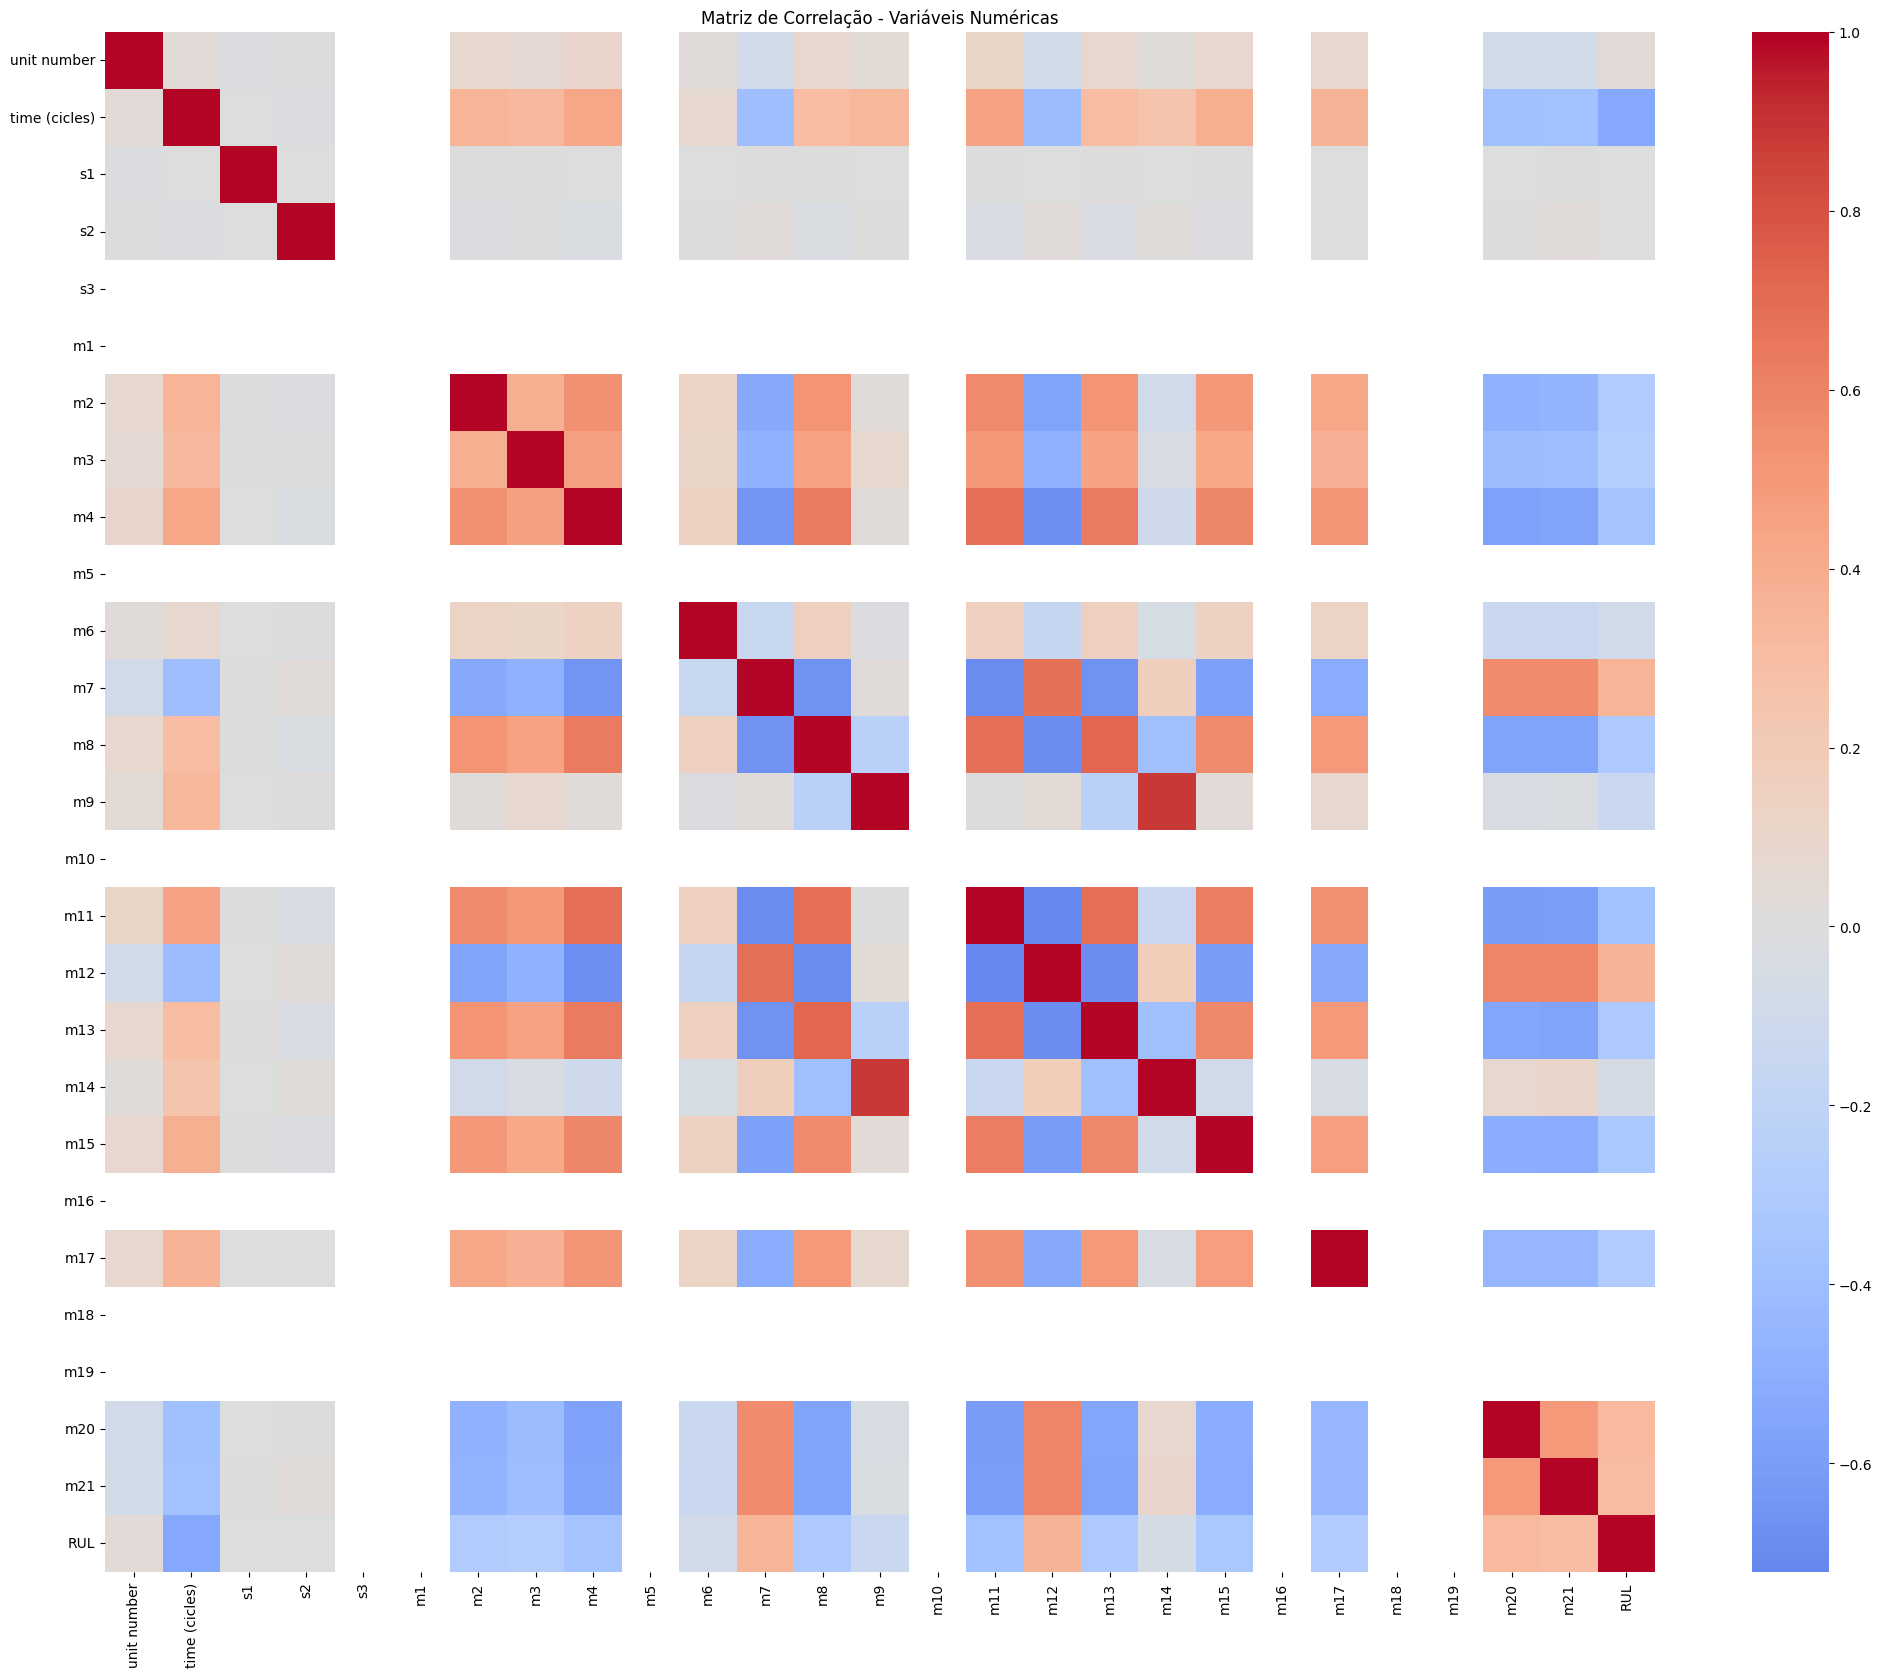

In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(25,20))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.show()

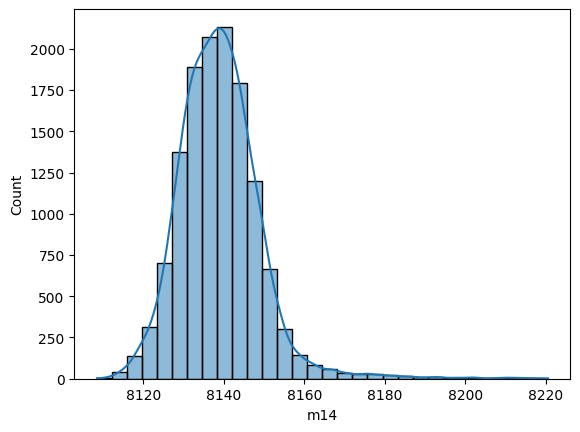

In [ ]:
sns.histplot(df["m14"], bins=30, kde=True)
plt.show()


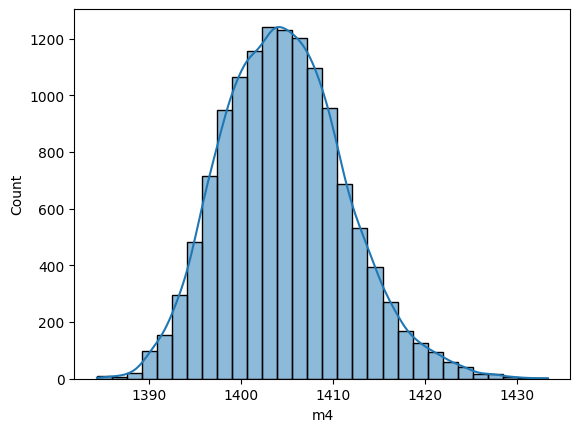

In [ ]:
sns.histplot(df["m4"], bins=30, kde=True)
plt.show()

In [ ]:
# Correlação de cada sensor com o RUL
correlacao = df.corr()['RUL'].drop('RUL').sort_values()
print(correlacao)

time (cicles)   -0.535027
m11             -0.375723
m4              -0.363288
m15             -0.322029
m13             -0.317450
m8              -0.313074
m2              -0.291652
m17             -0.286230
m3              -0.264494
m9              -0.132265
m6              -0.085906
m14             -0.058159
s1              -0.006978
s2              -0.004610
unit number      0.033629
m21              0.309917
m20              0.318195
m7               0.350578
m12              0.366830
s3                    NaN
m1                    NaN
m5                    NaN
m10                   NaN
m16                   NaN
m18                   NaN
m19                   NaN
Name: RUL, dtype: float64


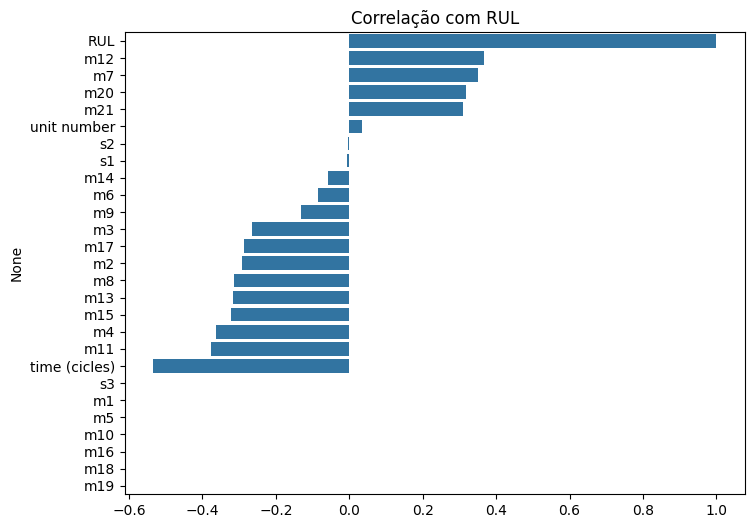

In [ ]:
corr = df.corr(numeric_only=True)["RUL"].sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Correlação com RUL")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Só os sensores com correlação relevante
sensores = ['m4', 'm7', 'm8', 'm11', 'm12', 'm13', 'm15', 'm17', 'm20', 'm21']

# Clipa o RUL máximo em 125
df['RUL'] = df['RUL'].clip(upper=125)

X = df[sensores]
y = df['RUL']

# Normaliza
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Divide treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Treino: {X_train.shape}')
print(f'Teste:  {X_test.shape}')

Treino: (10476, 10)
Teste:  (2620, 10)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Treina
modelo = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo.fit(X_train, y_train)

# Prevê
y_pred = modelo.predict(X_test)

# Avalia
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE:  {mae:.2f} ciclos')
print(f'RMSE: {rmse:.2f} ciclos')

MAE:  32.07 ciclos
RMSE: 37.74 ciclos


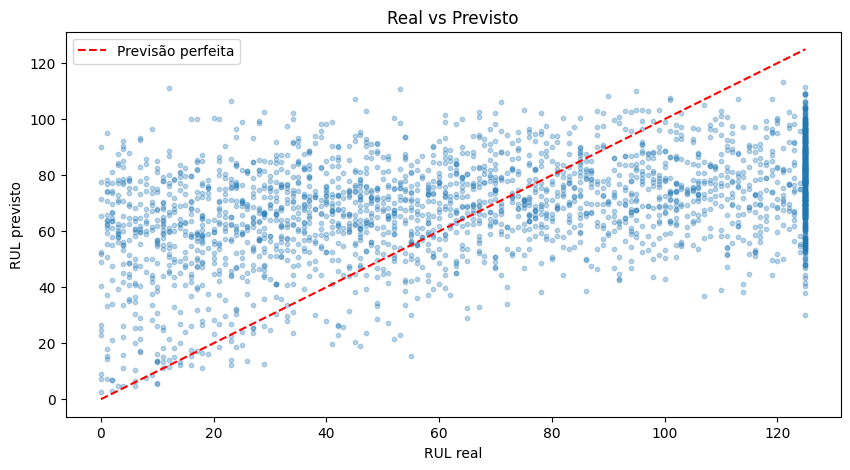

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([0, 125], [0, 125], 'r--', label='Previsão perfeita')
plt.xlabel('RUL real')
plt.ylabel('RUL previsto')
plt.title('Real vs Previsto')
plt.legend()
plt.show()

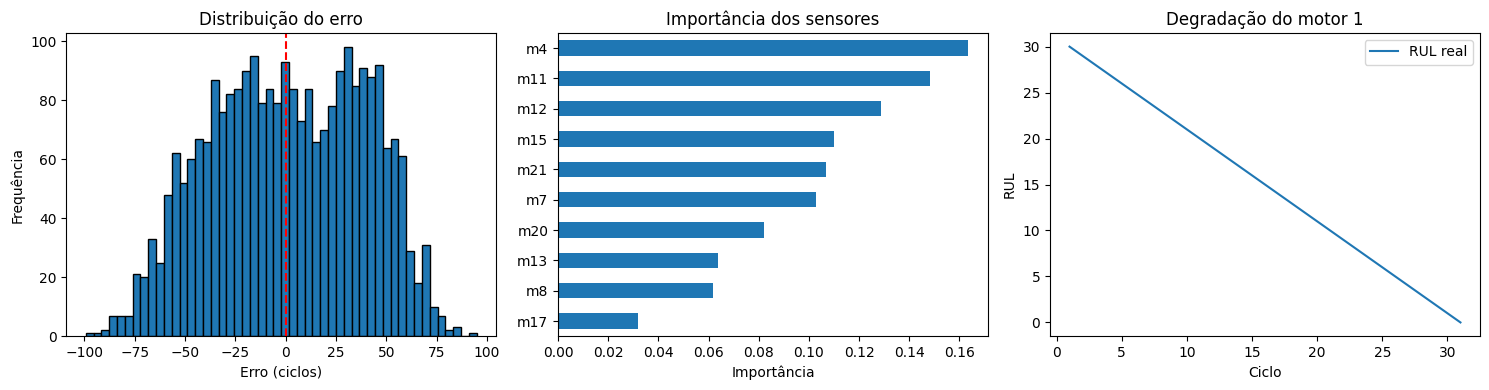

In [ ]:
# 1. Real vs Previsto (você já tem esse)
# 2. Distribuição do erro
erros = y_test - y_pred

plt.figure(figsize=(15, 4))

# Gráfico 1 - distribuição do erro
plt.subplot(1, 3, 1)
plt.hist(erros, bins=50, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Erro (ciclos)')
plt.ylabel('Frequência')
plt.title('Distribuição do erro')

# Gráfico 2 - importância de cada sensor
plt.subplot(1, 3, 2)
importancias = pd.Series(modelo.feature_importances_, index=sensores)
importancias.sort_values().plot(kind='barh')
plt.title('Importância dos sensores')
plt.xlabel('Importância')

# Gráfico 3 - degradação real de um motor
plt.subplot(1, 3, 3)
motor1 = df[df['unit number'] == 1].sort_values('time (cicles)')
plt.plot(motor1['time (cicles)'], motor1['RUL'], label='RUL real')
plt.xlabel('Ciclo')
plt.ylabel('RUL')
plt.title('Degradação do motor 1')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Quantos ciclos cada turbina durou
duracao = df.groupby('unit number')['time (cicles)'].max().sort_values(ascending=False)
print(duracao.head(10))

unit number
49     303
93     244
91     234
62     232
12     217
81     213
76     205
34     203
35     198
100    198
Name: time (cicles), dtype: int64


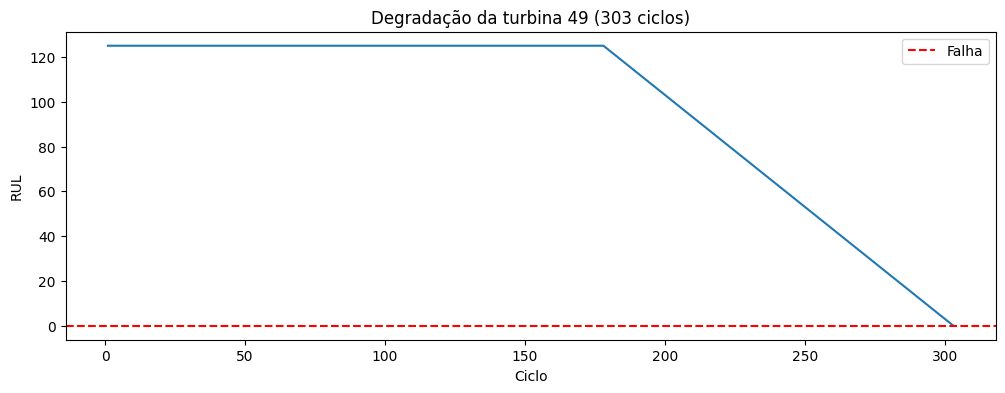

In [ ]:
# Plota a degradação de qualquer turbina
turbina = 49

motor = df[df['unit number'] == turbina].sort_values('time (cicles)')

plt.figure(figsize=(12, 4))
plt.plot(motor['time (cicles)'], motor['RUL'])
plt.xlabel('Ciclo')
plt.ylabel('RUL')
plt.title(f'Degradação da turbina {turbina} ({len(motor)} ciclos)')
plt.axhline(0, color='red', linestyle='--', label='Falha')
plt.legend()
plt.show()

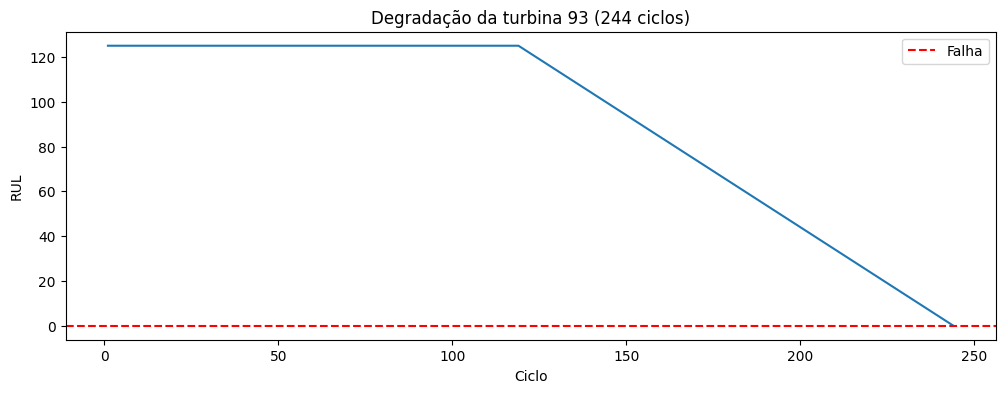

In [ ]:
# Plota a degradação de qualquer turbina
turbina = 93

motor = df[df['unit number'] == turbina].sort_values('time (cicles)')

plt.figure(figsize=(12, 4))
plt.plot(motor['time (cicles)'], motor['RUL'])
plt.xlabel('Ciclo')
plt.ylabel('RUL')
plt.title(f'Degradação da turbina {turbina} ({len(motor)} ciclos)')
plt.axhline(0, color='red', linestyle='--', label='Falha')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Normaliza
scaler = MinMaxScaler()
df[sensores] = scaler.fit_transform(df[sensores])

# Cria janelas de sequência
def criar_janelas(df, sensores, janela=30):
    X, y = [], []

    for unit in df['unit number'].unique():
        turbina = df[df['unit number'] == unit].sort_values('time (cicles)')

        sensor_vals = turbina[sensores].values
        rul_vals = turbina['RUL'].values

        for i in range(len(turbina) - janela):
            X.append(sensor_vals[i:i+janela])
            y.append(rul_vals[i+janela])

    return np.array(X), np.array(y)

X, y = criar_janelas(df, sensores, janela=30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')

X_train: (8076, 30, 10)
X_test:  (2020, 30, 10)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

modelo_lstm = Sequential([
    LSTM(64, input_shape=(30, 10), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

modelo_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

modelo_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5)
]

history = modelo_lstm.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 1579.8152 - mae: 34.2838 - val_loss: 1609.4408 - val_mae: 34.5893 - learning_rate: 0.0010
Epoch 2/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 1570.6189 - mae: 34.1156 - val_loss: 1609.2317 - val_mae: 34.5922 - learning_rate: 0.0010
Epoch 3/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 1583.0980 - mae: 34.2139 - val_loss: 1609.6891 - val_mae: 34.5860 - learning_rate: 0.0010
Epoch 4/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 1577.6876 - mae: 34.1217 - val_loss: 1609.4491 - val_mae: 34.5892 - learning_rate: 0.0010
Epoch 5/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 1574.8831 - mae: 34.2090 - val_loss: 1609.4520 - val_mae: 34.5892 - learning_rate: 0.0010
Epoch 6/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 1580.3774 - mae: 34.1939 - val_loss: 1609.3739 - val_mae: 34.5902 - learning_rate: 0.0010
Epoch 7/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 1580.7957 - mae: 34.2711 

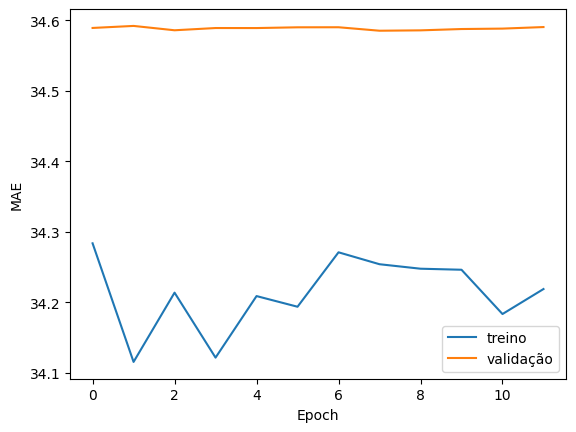

In [ ]:
plt.plot(history.history['mae'], label='treino')
plt.plot(history.history['val_mae'], label='validação')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()